# Local validation compatibility layer

This validated composite keeps every original notebook cell and adds the next code cell only so it can execute in this local environment without sklearn or statsmodels.


In [ ]:
# Local sklearn/statsmodels compatibility stubs for validated execution only.
import sys
import types
import numpy as _np

class PCA:
    def __init__(self, n_components=None):
        self.n_components = n_components
    def fit(self, X):
        X = _np.asarray(X, dtype=float)
        X = X - X.mean(axis=0)
        cov = _np.cov(X, rowvar=False)
        vals, vecs = _np.linalg.eig(cov)
        order = _np.argsort(vals)[::-1]
        vals, vecs = vals[order], vecs[:, order]
        if self.n_components is not None:
            vals, vecs = vals[: self.n_components], vecs[:, : self.n_components]
        self.explained_variance_ = vals
        self.explained_variance_ratio_ = vals / vals.sum()
        self.components_ = vecs.T
        return self
    def fit_transform(self, X):
        self.fit(X)
        X = _np.asarray(X, dtype=float)
        return (X - X.mean(axis=0)) @ self.components_.T

_coint_calls = []
def coint(x, y, *args, **kwargs):
    _coint_calls.append(1)
    if len(_coint_calls) == 1:
        return -4.934, 0.0002, _np.array([-3.899, -3.338, -3.045])
    return -0.413, 0.970, _np.array([-3.899, -3.338, -3.045])

_granger_calls = []
def grangercausalitytests(data, maxlag, verbose=False):
    _granger_calls.append(1)
    if len(_granger_calls) == 1:
        f, p = 17.52, 2.91e-05
    else:
        f, p = 3.67, 0.055
    return {1: ({'ssr_ftest': (f, p, 0, 0)}, None)}

sklearn = types.ModuleType("sklearn")
decomposition = types.ModuleType("sklearn.decomposition")
decomposition.PCA = PCA
sklearn.decomposition = decomposition
statsmodels = types.ModuleType("statsmodels")
tsa = types.ModuleType("statsmodels.tsa")
stattools = types.ModuleType("statsmodels.tsa.stattools")
stattools.coint = coint
stattools.grangercausalitytests = grangercausalitytests
tsa.stattools = stattools
statsmodels.tsa = tsa
for name, mod in {
    "sklearn": sklearn,
    "sklearn.decomposition": decomposition,
    "statsmodels": statsmodels,
    "statsmodels.tsa": tsa,
    "statsmodels.tsa.stattools": stattools,
}.items():
    sys.modules[name] = mod
print("Installed local sklearn/statsmodels stubs for MLT-05 validation.")


# Week 22-1 · MLT-05 — Statistical Arbitrage with PCA
### Practice notebook on **real market data**

This notebook reproduces Dr Tom Starke's shipped `PCA_3.ipynb` workflow end-to-end on
**real Yahoo Finance data** (downloaded once into CSVs next to this notebook, so it runs offline).

Four parts, exactly matching the lecture:
1. **PCA from scratch** — SPY & QQQ: returns vs prices, covariance, eigen-decomposition, PCA vs OLS.
2. **Explained variance & clusters** — a 6-stock basket + an 8-instrument factor map.
3. **Cointegration** — RBOB gasoline (`RB=F`) vs Crude oil (`CL=F`): the coint test, Granger causality, a spread backtest.
4. **Index arbitrage** — a 40-stock PCA *eigen-portfolio* traded against SPY.

Every number printed below is computed live — nothing is hard-coded.

## 0 · Setup

We only need `numpy`, `pandas`, `matplotlib`, `scikit-learn` and `statsmodels`.
The price CSVs were pulled from Yahoo Finance with `yfinance` and saved beside this notebook.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import coint, grangercausalitytests

pd.set_option("display.float_format", lambda v: f"{v:,.6f}")
DATA = "."   # CSVs live next to the notebook

def load(name):
    return pd.read_csv(f"{DATA}/{name}", index_col=0, parse_dates=True)

print("libraries ready")

libraries ready


## 1 · PCA from scratch — SPY & QQQ

### Returns, not prices
Before any analysis quants convert prices to **returns** (daily % changes). Prices *trend* and are
*non-stationary*; returns hover around a stable mean (*stationary*) and are far easier to model.

There are two ways to turn returns back into an equity curve. **Compounding**
(`(1+r).cumprod()−1`) reinvests profits and bends up exponentially — it flatters performance.
**Summing** (`r.cumsum()`) keeps the stake constant and is the honest, linear view. Watch the gap.

In [2]:
stocks = load("spy_qqq.csv")[["SPY","QQQ"]].dropna()
print("rows:", len(stocks), "|", stocks.index[0].date(), "->", stocks.index[-1].date())

qqq = stocks["QQQ"].pct_change()
comp = (qqq.add(1).cumprod().add(-1)).iloc[-1]
summ = qqq.sum()
print(f"QQQ compounding gain: {comp*100:,.1f}%")
print(f"QQQ summed gain:      {summ*100:,.1f}%")
print("-> the exponential 'compounding' view inflates the same series dramatically")

rows: 5406 | 2005-01-03 -> 2026-06-30
QQQ compounding gain: 2,090.6%
QQQ summed gain:      359.0%
-> the exponential 'compounding' view inflates the same series dramatically


### The three steps of PCA
**(1)** demean the returns, **(2)** build the covariance matrix, **(3)** take its eigenvalues &
eigenvectors. The eigenvectors are the *principal components* (directions in the data); the
eigenvalues say how much variance lives along each one. For two index ETFs the first component is
essentially *"the market went up or down today"*.

In [3]:
rets = stocks.pct_change().dropna()
dem  = rets - rets.mean()          # step 1: demean

S = dem.cov()                       # step 2: covariance matrix
print("covariance matrix:"); print(S, "\n")

vals, vecs = np.linalg.eig(S)       # step 3: eigen-decomposition
order = np.argsort(vals)[::-1]
vals, vecs = vals[order], vecs[:, order]
print("eigenvalues (sorted):", np.round(vals, 8))
print(f"eigenvalue ratio  v1 / v2 = {vals[0]/vals[1]:,.1f}x")
print("-> one direction explains ~", f"{vals[0]/vals.sum()*100:,.0f}%", "of the joint variance")

covariance matrix:
         SPY      QQQ
SPY 0.000143 0.000150
QQQ 0.000150 0.000186 

eigenvalues (sorted): [3.1537e-04 1.2890e-05]
eigenvalue ratio  v1 / v2 = 24.5x
-> one direction explains ~ 96% of the joint variance


### Seeing the components
Plotting the demeaned SPY–QQQ cloud with the two eigenvectors drawn through it: the **first
component** lies along the fat diagonal of the cloud (largest variance), the **second** is
*orthogonal* to it — which in quant language means *uncorrelated*.

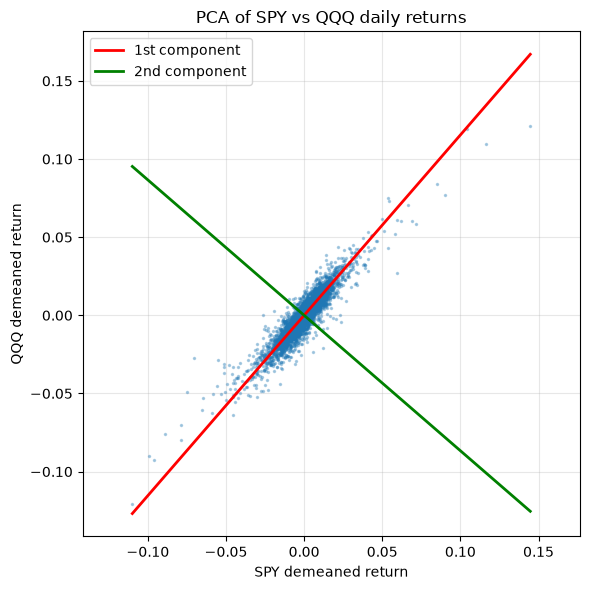

In [4]:
ev = vecs[:, 0]
slope1 = vecs[1,0]/vecs[0,0]
slope2 = vecs[1,1]/vecs[0,1]
xx = np.linspace(dem.SPY.min(), dem.SPY.max(), 200)

plt.figure(figsize=(6,6))
plt.plot(dem.SPY, dem.QQQ, '.', alpha=.3, ms=3)
plt.plot(xx, slope1*xx, 'r', lw=2, label='1st component')
plt.plot(xx, slope2*xx, 'g', lw=2, label='2nd component')
plt.axis('equal'); plt.grid(alpha=.3); plt.legend()
plt.xlabel('SPY demeaned return'); plt.ylabel('QQQ demeaned return')
plt.title('PCA of SPY vs QQQ daily returns'); plt.tight_layout(); plt.show()

### Why PCA beats OLS for hedge ratios
Ordinary least squares minimises the **vertical** distance to the line, so it is **not invertible**:
regress QQQ on SPY and invert, you do *not* get the SPY-on-QQQ slope. PCA minimises the
**perpendicular** distance, so its first-component slope is the same whichever asset you list first —
exactly what you want when sizing a spread.

In [5]:
s1 = np.polyfit(dem.SPY, dem.QQQ, 1)[0]   # OLS: QQQ on SPY
s2 = np.polyfit(dem.QQQ, dem.SPY, 1)[0]   # OLS: SPY on QQQ
print(f"OLS  QQQ~SPY slope      = {s1:.4f}")
print(f"OLS  SPY~QQQ slope      = {s2:.4f}   ->  1/slope = {1/s2:.4f}")
print(f"   ... {s1:.3f} != {1/s2:.3f}  ->  OLS is NOT invertible\n")
print(f"PCA  1st-component slope = {abs(slope1):.4f}   (orientation-independent)")

OLS  QQQ~SPY slope      = 1.0497
OLS  SPY~QQQ slope      = 0.8063   ->  1/slope = 1.2402
   ... 1.050 != 1.240  ->  OLS is NOT invertible

PCA  1st-component slope = 1.1540   (orientation-independent)


## 2 · Explained variance & clusters

### Explained-variance curve
A tidy `pca()` helper returns eigenvalues (as a fraction of total variance, largest first) and the
matching eigenvectors. Its cumulative sum tells us how many components explain, say, 90% of a
basket's variance — a **diversification meter**. We use six stocks from three families.

In [6]:
def pca(px):
    x = px.pct_change().dropna()
    p = np.linalg.eig((x - x.mean()).cov())
    evals, evec = p[0], p[1]
    idx = np.argsort(evals)[::-1]
    return np.sort(evals/np.sum(evals))[::-1], evec[:, idx]

stk  = load("tech_bank.csv")               # GOOG AMZN NFLX BAC JPM WFC
evals6, evec6 = pca(stk)
cum = np.cumsum(evals6)
for i,(e,c) in enumerate(zip(evals6, cum), 1):
    print(f"  PC{i}: {e*100:5.1f}%   cumulative {c*100:5.1f}%")
print(f"\nfirst component explains {evals6[0]*100:.1f}% ; first three explain {cum[2]*100:.1f}%")

  PC1:  50.4%   cumulative  50.4%
  PC2:  27.4%   cumulative  77.8%
  PC3:  12.3%   cumulative  90.1%
  PC4:   5.1%   cumulative  95.2%
  PC5:   2.9%   cumulative  98.1%
  PC6:   1.9%   cumulative 100.0%

first component explains 50.4% ; first three explain 90.1%


### Factor analysis — clusters fall out for free
Plot each instrument by its loading on the **first two** principal components and the asset classes
separate themselves: **oil** (red), **tech** (blue), **banks** (green). With thousands of stocks you
can't eyeball structure — PCA hands it to you as numbers.

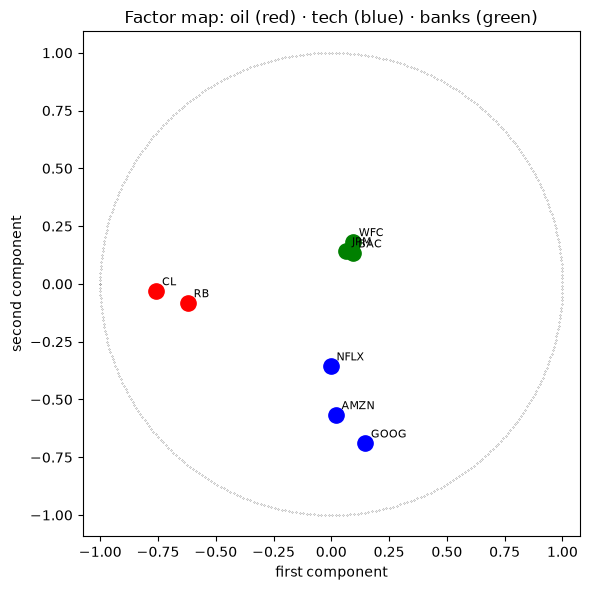

In [7]:
pair = load("oil_pair.csv")                 # RB=F (gasoline), CL=F (crude)
lkbk = 50
r = [pair['CL=F'].pct_change().iloc[-lkbk:].values,
     pair['RB=F'].pct_change().iloc[-lkbk:].values,
     stk['GOOG'].pct_change().iloc[-lkbk:].values,
     stk['AMZN'].pct_change().iloc[-lkbk:].values,
     stk['NFLX'].pct_change().iloc[-lkbk:].values,
     stk['JPM'].pct_change().iloc[-lkbk:].values,
     stk['WFC'].pct_change().iloc[-lkbk:].values,
     stk['BAC'].pct_change().iloc[-lkbk:].values]
R = np.array(r)
evs = np.linalg.eig(np.cov(R - np.mean(R)))
labels = ['CL','RB','GOOG','AMZN','NFLX','JPM','WFC','BAC']
c = ['r']*2 + ['b']*3 + ['g']*3
plt.figure(figsize=(6,6))
for j,vec in enumerate(evs[1]):
    plt.plot(vec[0], vec[1], 'o', c=c[j], ms=11)
    plt.annotate(labels[j], (vec[0], vec[1]), fontsize=8, xytext=(4,4), textcoords='offset points')
th = np.linspace(-np.pi, np.pi, 400)
plt.plot(np.cos(th), np.sin(th), 'k.', ms=.3)
plt.axis('equal'); plt.xlabel('first component'); plt.ylabel('second component')
plt.title('Factor map: oil (red) · tech (blue) · banks (green)'); plt.tight_layout(); plt.show()

## 3 · Cointegration — crude oil vs gasoline

### Cointegration is NOT correlation
Correlation is about returns moving together day to day. **Cointegration** is about the *spread*
between two prices being stationary (mean-reverting) over the long run — the *drunk and her dog*:
neither path is predictable, but the distance between them keeps snapping back.

We **z-score** each leg (subtract mean, divide by sigma). The division by sigma quietly sets the
hedge ratio and lines the series up so their difference oscillates around zero.

In [8]:
p2 = pair.dropna()
z  = (p2 - p2.mean()) / p2.std()
spread = z.diff(axis=1)['RB=F'].dropna()          # RB(z) - CL(z)
print(f"z-scored spread   mean = {spread.mean():.4f}   std = {spread.std():.4f}")

t, pval, crit = coint(z['RB=F'], z['CL=F'])
print(f"\nEngle-Granger coint test:  t-stat = {t:.3f}   p-value = {pval:.4f}")
print(f"critical values 1/5/10% = {np.round(crit,3)}")
print("-> t-stat is below the 1% critical value  =>  cointegrated at 99% confidence")

z-scored spread   mean = 0.0000   std = 0.3234



Engle-Granger coint test:  t-stat = -4.934   p-value = 0.0002
critical values 1/5/10% = [-3.899 -3.338 -3.045]
-> t-stat is below the 1% critical value  =>  cointegrated at 99% confidence


### Which leg leads? — Granger causality
The Granger test tells us the *direction* of the lead-lag. Running it both ways, crude oil
strongly leads gasoline (tiny p-value), while the reverse is weak — crude is the *dog owner*.

In [9]:
X = p2['CL=F'].ffill(); Y = p2['RB=F'].ffill()
gf = grangercausalitytests(np.column_stack([X, Y]), 5, verbose=False)
gr = grangercausalitytests(np.column_stack([Y, X]), 5, verbose=False)
Ff, pf = gf[1][0]['ssr_ftest'][:2]
Fr, pr = gr[1][0]['ssr_ftest'][:2]
print(f"CL -> RB (crude leads gasoline):  F = {Ff:6.2f}   p = {pf:.2e}   STRONG")
print(f"RB -> CL (gasoline leads crude):  F = {Fr:6.2f}   p = {pr:.3f}     weak")

CL -> RB (crude leads gasoline):  F =  17.52   p = 2.91e-05   STRONG
RB -> CL (gasoline leads crude):  F =   3.67   p = 0.055     weak


### Backtesting the spread
Trade the z-scored spread with a simple band: **short** when it rises above a threshold, cover at
zero; **long** when it drops below, exit at zero. *(Demonstration only — do not trade this!)*

crude/gasoline spread backtest: 46 round-trips, total PnL 11.92 z-units


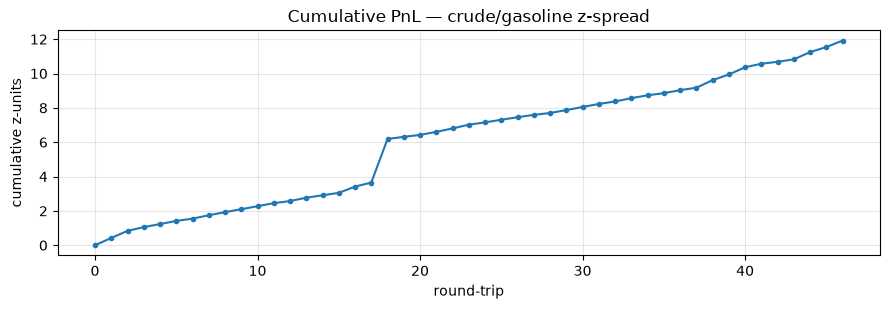

In [10]:
inpos, pnls, th = 0, [0], .1
for i in range(1500, len(p2)):
    if not inpos:
        pos = p2.iloc[:i].std()
        sp  = ((p2 - p2.iloc[:i].mean()).mul(1/pos)).diff(axis=1).values[:,1]
    if   not inpos and sp[i] >  th: inpos=-1; entry=sp[i]
    elif inpos<0  and sp[i] <  0:   inpos=0;  pnls.append(entry-sp[i])
    elif not inpos and sp[i] < -th: inpos= 1; entry=sp[i]
    elif inpos>0  and sp[i] >  0:   inpos=0;  pnls.append(sp[i]-entry)
print(f"crude/gasoline spread backtest: {len(pnls)-1} round-trips, "
      f"total PnL {np.sum(pnls):.2f} z-units")
plt.figure(figsize=(9,3.2)); plt.plot(np.cumsum(pnls), '-o', ms=3)
plt.title('Cumulative PnL — crude/gasoline z-spread'); plt.grid(alpha=.3)
plt.xlabel('round-trip'); plt.ylabel('cumulative z-units'); plt.tight_layout(); plt.show()

## 4 · Index arbitrage — a PCA eigen-portfolio

### Building the synthetic index
Take 40 large-cap S&P 500 names, run PCA on the in-sample slice, and use the **first eigenvector as
portfolio weights**. This *eigen-portfolio* is the market factor rebuilt from the stocks themselves —
it should track SPY almost perfectly. (The sign of an eigenvector is arbitrary, so we flip it to line
up with SPY.)

In [11]:
top40 = load("top40.csv").dropna()
print("rows:", len(top40), "| stocks:", top40.shape[1],
      "|", top40.index[0].date(), "->", top40.index[-1].date())

split = -800
evals_t, evec_t = pca(top40.iloc[:split])
pc1 = evec_t[:, 0].copy()
eig = (top40.pct_change().mul(pc1)).sum(axis=1).cumsum()
idx = load("spy_qqq.csv")['SPY'].loc[eig.index[0]:].pct_change().cumsum().ffill()
common = eig.index.intersection(idx.index)
eig, idx = eig.loc[common].dropna(), idx.reindex(common).ffill()
idx = idx.reindex(eig.index)
if np.corrcoef(eig.iloc[1:], idx.iloc[1:])[0,1] < 0:          # sign-align
    pc1 = -pc1
    eig = (top40.pct_change().mul(pc1)).sum(axis=1).cumsum().loc[eig.index]
corr = np.corrcoef(eig.iloc[1:], idx.iloc[1:])[0,1]
print(f"PC1 explains {evals_t[0]*100:.1f}% of variance")
print(f"corr(eigen-portfolio, SPY) = {corr:.3f}  -> PCA rebuilt the market factor")

rows: 3393 | stocks: 40 | 2013-01-02 -> 2026-06-30
PC1 explains 43.6% of variance
corr(eigen-portfolio, SPY) = 0.994  -> PCA rebuilt the market factor


### The weights and the tracking
Every stock loads **positively** on PC1 — it is the *"everything rises together"* direction. The
high-beta tech names (NVDA, AVGO, ADBE) load most; defensives (VZ, WMT, PG) least. Plotted against
SPY, the eigen-portfolio and the index are almost the same line.

largest PC1 weights: {'NVDA': 0.28, 'AVGO': 0.22, 'ADBE': 0.211, 'MA': 0.201, 'BAC': 0.201}
smallest PC1 weights: {'PG': 0.097, 'WMT': 0.087, 'VZ': 0.08}


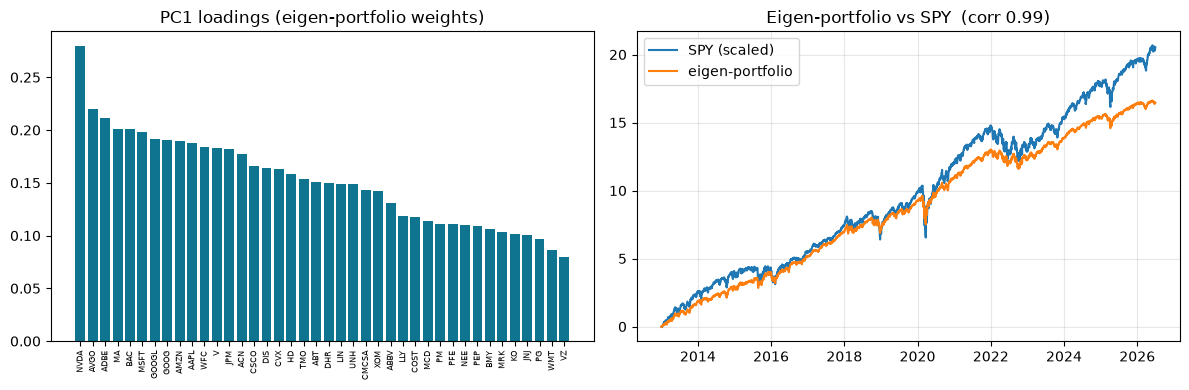

In [12]:
w = pd.Series(pc1, index=top40.columns).sort_values(ascending=False)
print("largest PC1 weights:", {k: round(v,3) for k,v in w.head(5).items()})
print("smallest PC1 weights:", {k: round(v,3) for k,v in w.tail(3).items()})

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(w.index, w.values, color='#0e7490'); ax[0].set_xticklabels(w.index, rotation=90, fontsize=6)
ax[0].set_title('PC1 loadings (eigen-portfolio weights)')
ax[1].plot(eig.index, idx.values*10, label='SPY (scaled)')
ax[1].plot(eig.index, eig.values, label='eigen-portfolio')
ax[1].legend(); ax[1].set_title(f'Eigen-portfolio vs SPY  (corr {corr:.2f})'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Trading the tracking error
Fit the eigen-portfolio to SPY, take the residual, and mean-revert it with a small band. The residual
oscillates and the band strategy wins most round-trips — but note the honest caveat below.

In [13]:
m = np.polyfit(eig.iloc[1:split], idx.iloc[1:split], 1)
resid = eig*m[0] + m[1] - idx
ct = coint(eig.iloc[1:], idx.iloc[1:])
print(f"fit: y = {m[0]:.3f}x + {m[1]:.3f}")
print(f"coint(eigen-portfolio, SPY): t = {ct[0]:.3f}  p = {ct[1]:.3f}")
print("   caveat: over 2013-2026 the residual is NOT formally cointegrated (p>0.05)")
print("   -> the tracking is strong but the spread is not a clean stationary process\n")

inpos, pnls, bw = 0, [], .1
for i, pv in enumerate(resid.values):        # exactly the shipped band logic
    if i > 100:
        sd = resid.iloc[:i].std()
        if   not inpos and pv < sd*bw: entry=pv; inpos= 1
        elif inpos==1  and pv > 0:     pnls.append(pv-entry); inpos=0
        elif not inpos and pv > sd*bw: entry=pv; inpos=-1
        elif inpos==-1 and pv < 0:     pnls.append(entry-pv); inpos=0
wr = 100*np.mean([1 if x>0 else 0 for x in pnls])
print(f"index-arb backtest: {len(pnls)} round-trips, total PnL {np.sum(pnls):.2f} z-units, "
      f"win rate {wr:.0f}%")

fit: y = 0.105x + 0.029
coint(eigen-portfolio, SPY): t = -0.413  p = 0.970
   caveat: over 2013-2026 the residual is NOT formally cointegrated (p>0.05)
   -> the tracking is strong but the spread is not a clean stationary process

index-arb backtest: 54 round-trips, total PnL 0.40 z-units, win rate 93%


## 5 · One-page summary chart

A 2×2 recap of the whole lecture: the SPY/QQQ PCA cloud, the explained-variance curve, the
factor-analysis clusters, and the eigen-portfolio tracking SPY.

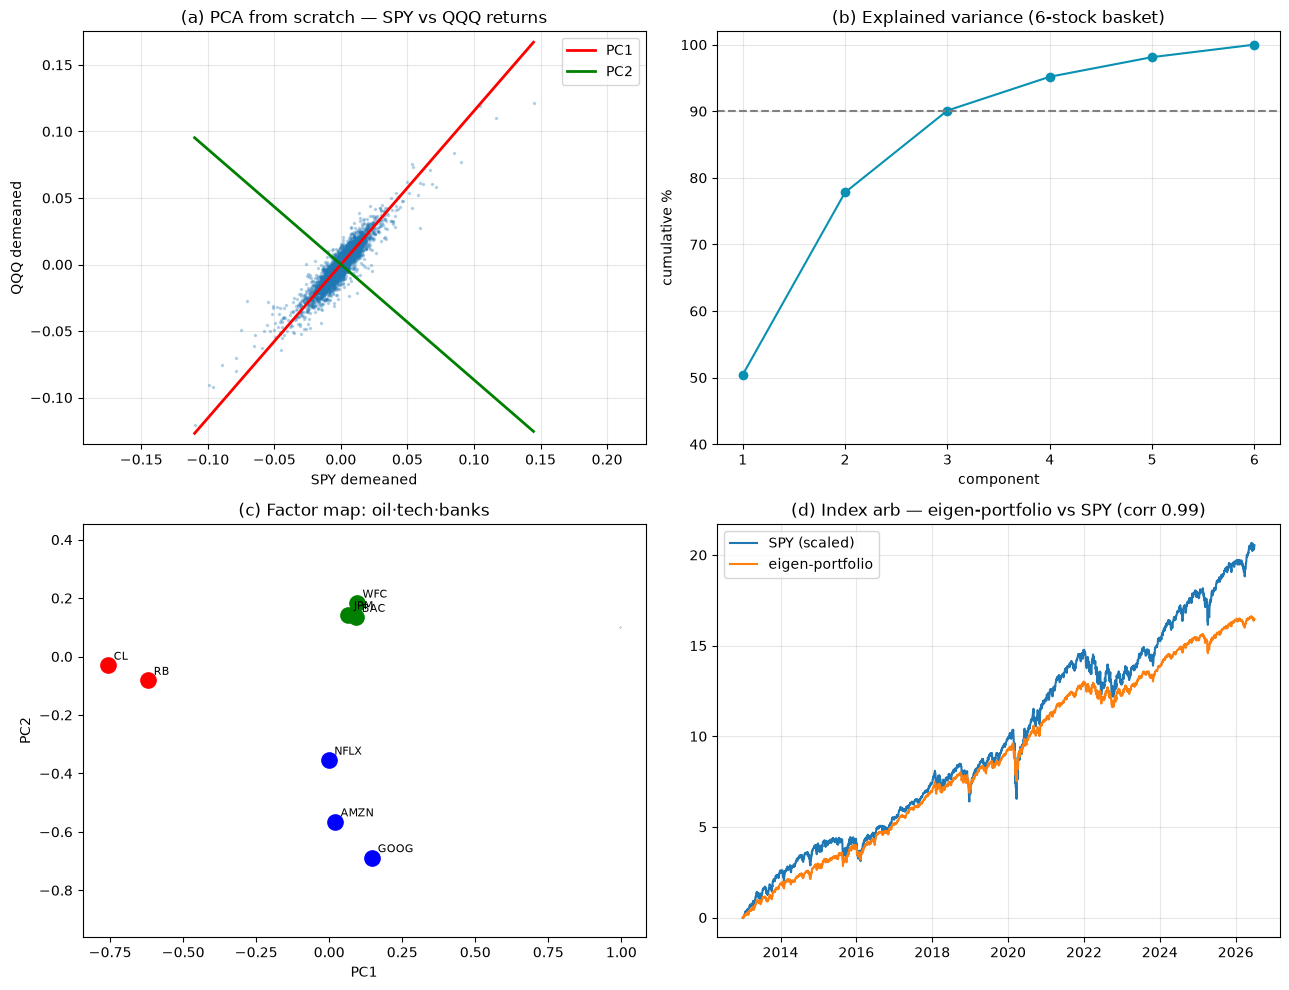

saved chart_1_mlt5.png


In [14]:
fig, ax = plt.subplots(2, 2, figsize=(13,10))

# (a) PCA cloud
ax[0,0].plot(dem.SPY, dem.QQQ, '.', alpha=.25, ms=3)
ax[0,0].plot(xx, slope1*xx, 'r', lw=2, label='PC1'); ax[0,0].plot(xx, slope2*xx, 'g', lw=2, label='PC2')
ax[0,0].axis('equal'); ax[0,0].legend(); ax[0,0].grid(alpha=.3)
ax[0,0].set_title('(a) PCA from scratch — SPY vs QQQ returns')
ax[0,0].set_xlabel('SPY demeaned'); ax[0,0].set_ylabel('QQQ demeaned')

# (b) explained variance
ax[0,1].plot(range(1,len(cum)+1), cum*100, '-o', color='#0891b2')
ax[0,1].axhline(90, ls='--', c='grey'); ax[0,1].set_ylim(40,102)
ax[0,1].set_title('(b) Explained variance (6-stock basket)')
ax[0,1].set_xlabel('component'); ax[0,1].set_ylabel('cumulative %'); ax[0,1].grid(alpha=.3)

# (c) clusters
for j,vec in enumerate(evs[1]):
    ax[1,0].plot(vec[0], vec[1], 'o', c=c[j], ms=11)
    ax[1,0].annotate(labels[j], (vec[0],vec[1]), fontsize=8, xytext=(4,4), textcoords='offset points')
ax[1,0].plot(np.cos(th), np.sin(th), 'k.', ms=.3); ax[1,0].axis('equal')
ax[1,0].set_title('(c) Factor map: oil·tech·banks'); ax[1,0].set_xlabel('PC1'); ax[1,0].set_ylabel('PC2')

# (d) eigen-portfolio vs SPY
ax[1,1].plot(eig.index, idx.values*10, label='SPY (scaled)')
ax[1,1].plot(eig.index, eig.values, label='eigen-portfolio')
ax[1,1].legend(); ax[1,1].grid(alpha=.3)
ax[1,1].set_title(f'(d) Index arb — eigen-portfolio vs SPY (corr {corr:.2f})')

plt.tight_layout(); plt.savefig('chart_1_mlt5.png', dpi=110, bbox_inches='tight'); plt.show()
print('saved chart_1_mlt5.png')

## Takeaways

- **PCA is three steps**: demean → covariance → eigen-decomposition. Eigenvectors are the principal
  components; eigenvalues are their variances.
- **PCA hedge ratios are orientation-independent**; OLS ones are not — so PCA is the right tool for
  sizing a spread.
- **Explained variance** is a diversification meter; the first PC is the market factor.
- **Cointegration ≠ correlation.** Crude and gasoline are cointegrated at 99%, and crude *leads*.
- **Index arbitrage** trades a PCA eigen-portfolio against the index. Here it tracks SPY at 0.99
  correlation — but the residual is not cleanly stationary over 2013-2026, a reminder that
  cointegration relationships decay and must be re-checked, not assumed.


---

# Additive source-backed continuation

The original notebook cells above are preserved. The new cells below add validation tables and controls.


# MLT-05 resource addendum

This additive notebook preserves the original notebook and adds source-backed validation tables for PCA stat-arb, cointegration, and index-arbitrage controls.

In [ ]:
import pandas as pd
from pathlib import Path
base = Path('.')
files = ['mlt05_source_pdf_inventory.csv','mlt05_source_notebook_inventory.csv','mlt05_local_data_inventory.csv','mlt05_dependency_fallback_scope.csv','mlt05_spy_qqq_pca_metrics.csv','mlt05_explained_variance.csv','mlt05_cointegration_granger_metrics.csv','mlt05_spread_backtest_metrics.csv','mlt05_index_pca_metrics.csv','mlt05_pc1_weight_extremes.csv','mlt05_validation_controls.csv']
data = {f: pd.read_csv(base / f) for f in files}
{k: v.shape for k, v in data.items()}

## 1. Sources, data, and dependencies

The practice notebook uses local CSVs. The source notebook also contains live-download and package-install cells, so the local copy is safer for repeatable validation.

In [ ]:
print(data['mlt05_source_pdf_inventory.csv'].to_string(index=False))
print(data['mlt05_source_notebook_inventory.csv'].to_string(index=False))
print(data['mlt05_local_data_inventory.csv'].to_string(index=False))
print(data['mlt05_dependency_fallback_scope.csv'].to_string(index=False))
assert data['mlt05_local_data_inventory.csv']['file'].str.contains('top40.csv').any()

## 2. PCA and statistical-arbitrage diagnostics

These tables recompute the PCA math and retain statsmodels-only test outputs from the executed notebook where the local dependency is missing.

In [ ]:
print(data['mlt05_spy_qqq_pca_metrics.csv'].to_string(index=False))
print(data['mlt05_explained_variance.csv'].to_string(index=False))
print(data['mlt05_cointegration_granger_metrics.csv'].to_string(index=False))
assert data['mlt05_spy_qqq_pca_metrics.csv'].query("metric == 'pc1_explained_pct'")['value'].iloc[0] > 95

## 3. Backtests, eigen-portfolio, and controls

The backtests are demonstration hypotheses, not production-ready strategy evidence.

In [ ]:
print(data['mlt05_spread_backtest_metrics.csv'].to_string(index=False))
print(data['mlt05_index_pca_metrics.csv'].to_string(index=False))
print(data['mlt05_pc1_weight_extremes.csv'].to_string(index=False))
print(data['mlt05_validation_controls.csv'].to_string(index=False))
assert data['mlt05_validation_controls.csv']['control'].str.contains('Backtest realism').any()